In [1]:
# Side experiment: autoencoder, on the SAME 60/20/20 split as the rest of the project.
# Trained on legitimate TRAIN rows only. Scored on VALIDATION only, so the TEST set
# stays untouched. No tuning is done here, so nothing is chosen using these numbers.
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve
from fraud_detection.data import load_data, split_data

X, y = load_data()
X_train, X_val, _, y_train, y_val, _ = split_data(X, y)  # test split discarded here
print(f"train rows={len(y_train):,} (frauds={int(y_train.sum())})   validation rows={len(y_val):,} (frauds={int(y_val.sum())})")

train rows=170,883 (frauds=295)   validation rows=56,962 (frauds=99)


In [2]:
# This is the core trick of the whole approach
X_train_legit = X_train[y_train == 0]
print(f"Training the autoencoder on {len(X_train_legit)} legitimate transactions only")
print("(Fraud examples are completely excluded from training: the model never sees them)")

scaler = StandardScaler()
X_train_legit_scaled = scaler.fit_transform(X_train_legit)  # fit on legitimate train rows only
X_val_scaled = scaler.transform(X_val)

Training the autoencoder on 170588 legitimate transactions only
(Fraud examples are completely excluded from training: the model never sees them)


In [3]:
import sys
print(sys.executable)

C:\Users\Lenovo\fraud-detection\venv\Scripts\python.exe


In [4]:
import torch
import torch.nn as nn

n_features = X_train_legit_scaled.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 20),
            nn.ReLU(),
            nn.Linear(20, 10),   # the bottleneck
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, n_features)  # reconstruct back to original size
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder(n_features).to(device)
print(model)
print(f"Using device: {device}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=30, bias=True)
  )
)
Using device: cpu


In [5]:
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_legit_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # input = target
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30
model.train()
for epoch in range(n_epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

Epoch 5/30, Loss: 0.4533


Epoch 10/30, Loss: 0.4162


Epoch 15/30, Loss: 0.3913


Epoch 20/30, Loss: 0.3719


Epoch 25/30, Loss: 0.3661


Epoch 30/30, Loss: 0.3630


In [6]:
model.eval()
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    reconstructions = model(X_val_tensor).cpu().numpy()

mse = np.mean(np.square(X_val_scaled - reconstructions), axis=1)

print(f"Mean reconstruction error (legitimate): {mse[y_val == 0].mean():.4f}")
print(f"Mean reconstruction error (fraud):      {mse[y_val == 1].mean():.4f}")

Mean reconstruction error (legitimate): 0.3763
Mean reconstruction error (fraud):      18.0910


In [7]:
auprc_ae = average_precision_score(y_val, mse)
print(f"Autoencoder validation AUPRC: {auprc_ae:.4f}")
print("(Compare to the supervised XGBoost validation AUPRC in the next cells and in reports/metrics.json)")

Autoencoder validation AUPRC: 0.2321
(Compare to the supervised XGBoost validation AUPRC in the next cells and in reports/metrics.json)


In [8]:
legit_errors = mse[y_val.values == 0]
fraud_errors = mse[y_val.values == 1]

print("Legitimate reconstruction error:")
print(pd.Series(legit_errors).describe())
print("\nFraud reconstruction error:")
print(pd.Series(fraud_errors).describe())

Legitimate reconstruction error:
count    56863.000000
mean         0.376321
std          1.965681
min          0.004600
25%          0.111410
50%          0.205767
75%          0.372332
max        202.677603
dtype: float64

Fraud reconstruction error:
count    99.000000
mean     18.090980
std      23.761379
min       0.059977
25%       1.907704
50%       6.635062
75%      24.014684
max      74.212268
dtype: float64


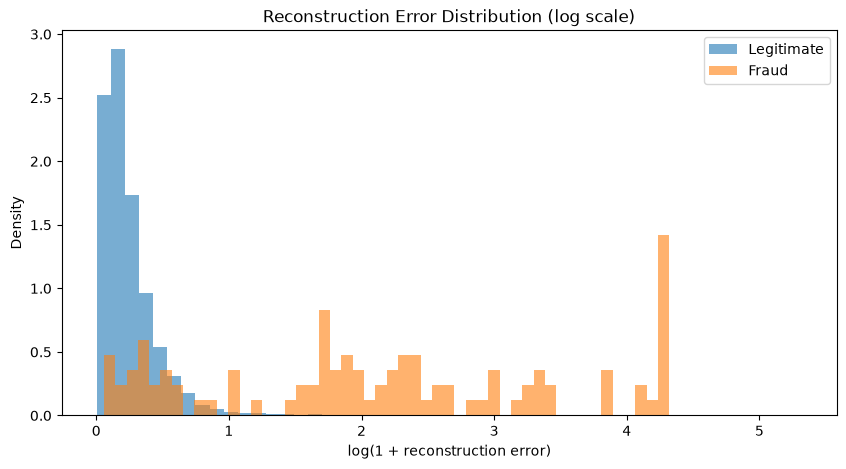

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(legit_errors), bins=50, alpha=0.6, label='Legitimate', density=True)
plt.hist(np.log1p(fraud_errors), bins=50, alpha=0.6, label='Fraud', density=True)
plt.xlabel('log(1 + reconstruction error)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution (log scale)')
plt.legend()
plt.savefig("../outputs/06_autoencoder_error_dist.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from fraud_detection.train import make_xgboost

# Supervised comparison: class-weighted XGBoost trained on the same train rows.
base_model = make_xgboost(y_train)
base_model.fit(X_train, y_train)
proba_xgb_val = base_model.predict_proba(X_val)[:, 1]
print(f"XGBoost validation AUPRC (same split): {average_precision_score(y_val, proba_xgb_val):.4f}")

XGBoost validation AUPRC (same split): 0.8086


In [11]:
# Which fraud cases does the autoencoder score LOW (i.e. miss)?
fraud_mask = (y_val == 1).values
fraud_indices = np.where(fraud_mask)[0]
low_error_fraud = fraud_indices[mse[fraud_mask] < np.median(mse[fraud_mask])]

# Compare: what does XGBoost say about the frauds the autoencoder misses?
print("Autoencoder-missed validation frauds: what does XGBoost say about them?")
print(pd.Series(proba_xgb_val[low_error_fraud]).describe())

Autoencoder-missed validation frauds: what does XGBoost say about them?
count    4.900000e+01
mean     5.552307e-01
std      4.871639e-01
min      3.637109e-07
25%      2.175293e-04
50%      9.616131e-01
75%      9.997990e-01
max      9.999989e-01
dtype: float64
